# **TikTok Project**
**Course 4 - Regression Analysis: Simplify complex data relationships**

In [1]:
import numpy as np
import pandas as pd
import platform
import statsmodels

print('Python version: ', platform.python_version())
print('numpy version: ', np.__version__)
print('pandas version: ', pd.__version__)
print('statsmodels version: ', statsmodels.__version__)

Python version:  3.11.4
numpy version:  1.24.4
pandas version:  2.0.3
statsmodels version:  0.14.0


You are a data professional at TikTok. The data team is working towards building a machine learning model that can be used to determine whether a video contains a claim or whether it offers an opinion. With a successful prediction model, TikTok can reduce the backlog of user reports and prioritize them more efficiently.

The team is getting closer to completing the project, having completed an initial plan of action, initial Python coding work, EDA, and hypothesis testing.

The TikTok team has reviewed the results of the hypothesis testing. TikTok’s Operations Lead, Maika Abadi, is interested in how different variables are associated with whether a user is verified. Earlier, the data team observed that if a user is verified, they are much more likely to post opinions. Now, the data team has decided to explore how to predict verified status to help them understand how video characteristics relate to verified users. Therefore, you have been asked to conduct a logistic regression using verified status as the outcome variable. The results may be used to inform the final model related to predicting whether a video is a claim vs an opinion.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

# **Course 4 End-of-course project: Regression modeling**


In this activity, you will build a logistic regression model in Python. As you have learned, logistic regression helps you estimate the probability of an outcome. For data science professionals, this is a useful skill because it allows you to consider more than one variable against the variable you're measuring against. This opens the door for much more thorough and flexible analysis to be completed.

<br/>

**The purpose** of this project is to demostrate knowledge of EDA and regression models.

**The goal** is to build a logistic regression model and evaluate the model.
<br/>
*This activity has three parts:*

**Part 1:** EDA & Checking Model Assumptions
* What are some purposes of EDA before constructing a logistic regression model?

**Part 2:** Model Building and Evaluation
* What resources do you find yourself using as you complete this stage?

**Part 3:** Interpreting Model Results

* What key insights emerged from your model(s)?

* What business recommendations do you propose based on the models built?

Follow the instructions and answer the question below to complete the activity. Then, you will complete an executive summary using the questions listed on the PACE Strategy Document.

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work.


# **Build a regression model**

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**

Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## **PACE: Plan**
Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

### **Task 1. Imports and loading**
Import the data and packages that you've learned are needed for building regression models.

In [2]:
# Import packages for data manipulation
### YOUR CODE HERE ###

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
import sklearn.metrics as metrics 
from sklearn.metrics import RocCurveDisplay 
from sklearn.utils import resample


Load the TikTok dataset.

**Note:** As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [3]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

<img src="images/Analyze.png" width="100" height="100" align=left>

## **PACE: Analyze**

Consider the questions in your PACE Strategy Document to reflect on the Analyze stage.

In this stage, consider the following question where applicable to complete your code response:

* What are some purposes of EDA before constructing a logistic regression model?


==> 1. Understand the dataset to determine whether meaningful insights can be extracted ( What is the distribution or proportion of the variabels?,
       Is there sufficient infomation to answer stakeholders' question and provide actionable recommendations?, 
       Are there potential errors, inconsistencies, or missing values in the dataset?) 
    2. Validate model assumptions 
    3. Decide on modeling decisions 

### **Task 2a. Explore data with EDA**

Analyze the data and check for and handle missing values and duplicates.

Inspect the first five rows of the dataframe.

In [4]:
# Display first few rows
### YOUR CODE HERE ###
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Get the number of rows and columns in the dataset.

In [5]:
# Get number of rows and columns
### YOUR CODE HERE ###
data.shape

(19382, 12)

Get the data types of the columns.

In [6]:
# Get data types of columns
### YOUR CODE HERE ###
 
for col in data.columns: 
    print(f'\n{col}')
    print(data[col].apply(type).value_counts()) 


#
#
<class 'int'>    19382
Name: count, dtype: int64

claim_status
claim_status
<class 'str'>      19084
<class 'float'>      298
Name: count, dtype: int64

video_id
video_id
<class 'int'>    19382
Name: count, dtype: int64

video_duration_sec
video_duration_sec
<class 'int'>    19382
Name: count, dtype: int64

video_transcription_text
video_transcription_text
<class 'str'>      19084
<class 'float'>      298
Name: count, dtype: int64

verified_status
verified_status
<class 'str'>    19382
Name: count, dtype: int64

author_ban_status
author_ban_status
<class 'str'>    19382
Name: count, dtype: int64

video_view_count
video_view_count
<class 'float'>    19382
Name: count, dtype: int64

video_like_count
video_like_count
<class 'float'>    19382
Name: count, dtype: int64

video_share_count
video_share_count
<class 'float'>    19382
Name: count, dtype: int64

video_download_count
video_download_count
<class 'float'>    19382
Name: count, dtype: int64

video_comment_count
video_comment_cou

Get basic information about the dataset.

In [7]:
# Get basic information
### YOUR CODE HERE ###
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


Generate basic descriptive statistics about the dataset.

In [8]:
# Generate basic descriptive stats
### YOUR CODE HERE ###
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


Check for and handle missing values.

In [9]:
# Check for missing values
### YOUR CODE HERE ###
data.isnull().sum()

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [10]:
# Drop rows with missing values
### YOUR CODE HERE ###
data = data[~data.isnull().any(axis = 1)]

In [11]:
# Display first few rows after handling missing values
### YOUR CODE HERE ###
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Check for and handle duplicates.

In [12]:
# Check for duplicates
### YOUR CODE HERE ###
data.duplicated(subset = '#').sum() 

0

Check for and handle outliers.

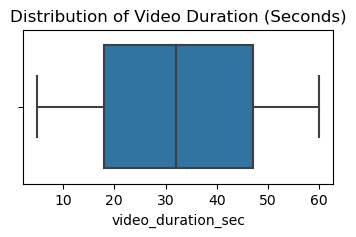

In [13]:
# Create a boxplot to visualize distribution of `video_duration_sec`
### YOUR CODE HERE ###

plt.figure(figsize = (4,2))

sns.boxplot(x = 'video_duration_sec', data = data) 

plt.title('Distribution of Video Duration (Seconds)') 
plt.show() 

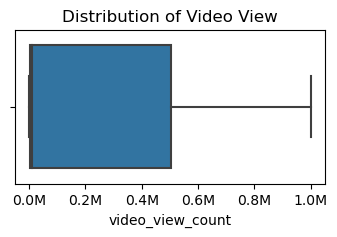

In [14]:
# Create a boxplot to visualize distribution of `video_view_count`
### YOUR CODE HERE ###

plt.figure(figsize = (4,2))

sns.boxplot(x = 'video_view_count', data = data) 



plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.title('Distribution of Video View') 
plt.show() 

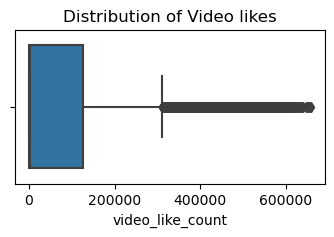

In [15]:
# Create a boxplot to visualize distribution of `video_like_count`
### YOUR CODE HERE ###

plt.figure(figsize = (4,2))

sns.boxplot(x = 'video_like_count', data = data) 

plt.title('Distribution of Video likes') 
plt.show() 

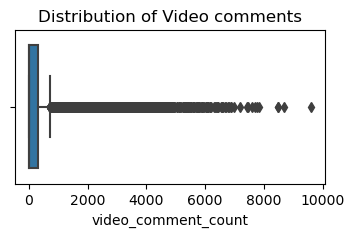

In [16]:
# Create a boxplot to visualize distribution of `video_comment_count`
### YOUR CODE HERE ###

plt.figure(figsize = (4,2))

sns.boxplot(x = 'video_comment_count', data = data) 

plt.title('Distribution of Video comments') 
plt.show() 

In [17]:
# Check for and handle outliers for video_like_count
### YOUR CODE HERE ###

# Handling these outliers carries certain risks for the following reasons: 
# 1. These outliers are not data error 
# 2. They reflect real viral behavior
# 3. Removing them could distort the true distriution

Check class balance of the target variable. Remember, the goal is to predict whether the user of a given post is verified or unverified.

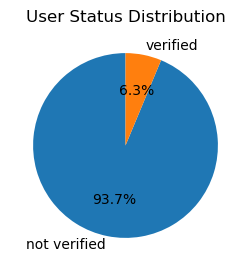

In [18]:
# Check class balance
### YOUR CODE HERE ###
plt.figure(figsize = (6,3)) 

plt.pie(
    data['verified_status'].value_counts(),
    labels= ['not verified','verified'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('User Status Distribution')
plt.show()

In [19]:
data['verified_status'].value_counts()

verified_status
not verified    17884
verified         1200
Name: count, dtype: int64

Approximately 94.2% of the dataset represents videos posted by unverified accounts and 5.8% represents videos posted by verified accounts. So the outcome variable is not very balanced.

Use resampling to create class balance in the outcome variable, if needed.

In [20]:
# Use resampling to create class balance in the outcome variable, if needed



# Identify data points from majority and minority classes
### YOUR CODE HERE ###

data_majority = data[data['verified_status'] == 'not verified']
data_minority = data[data['verified_status'] == 'verified']

# Upsample the minority class (which is "verified")
### YOUR CODE HERE ###


data_minority_upsampled = resample(data_minority,
                                 replace=True,                 
                                 n_samples=len(data_majority), 
                                 random_state=42)               

# Combine majority class with upsampled minority class
### YOUR CODE HERE ###
data_balanced = pd.concat([data_majority, data_minority_upsampled]).reset_index(drop = True) 

# Display new class counts
### YOUR CODE HERE ###

data_balanced['verified_status'].value_counts() 

verified_status
not verified    17884
verified        17884
Name: count, dtype: int64

Get the average `video_transcription_text` length for videos posted by verified accounts and the average `video_transcription_text` length for videos posted by unverified accounts.



In [21]:
# Get the average `video_transcription_text` length for claims and the average `video_transcription_text` length for opinions
### YOUR CODE HERE ###
for i in ['verified', 'not verified']: 
    print(f'\n{i}') 
    print(data_balanced[data_balanced['verified_status'] == i ]['video_transcription_text'].str.len().mean())
    
data_balanced['text_length'] = data_balanced['video_transcription_text'].apply(func=lambda text: len(text))


verified
84.56301722209797

not verified
89.40114068441065


Extract the length of each `video_transcription_text` and add this as a column to the dataframe, so that it can be used as a potential feature in the model.

In [22]:
# Display first few rows of dataframe after adding new column
### YOUR CODE HERE ###
data_balanced.head() 

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,97
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,107
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,137
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,131
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,128


Visualize the distribution of `video_transcription_text` length for videos posted by verified accounts and videos posted by unverified accounts.

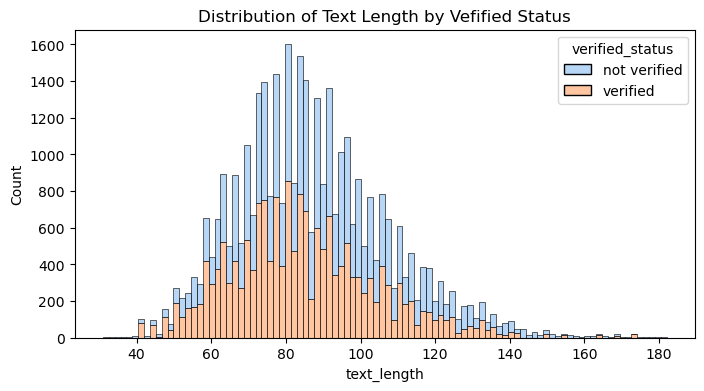

In [23]:
# Visualize the distribution of `video_transcription_text` length for videos posted by verified accounts and videos posted by unverified accounts
# Create two histograms in one plot
### YOUR CODE HERE ###
plt.figure(figsize = (8,4))
sns.histplot(x = 'text_length', data = data_balanced, multiple = 'stack',  palette='pastel', hue = 'verified_status', legend = True) 

plt.title('Distribution of Text Length by Vefified Status') 
plt.show() 

### **Task 2b. Examine correlations**

Next, code a correlation matrix to help determine most correlated variables.

In [24]:
# Code a correlation matrix to help determine most correlated variables
### YOUR CODE HERE ###
data_balanced.corr(numeric_only = True) 

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
#,1.000000,-0.001369,-0.011800,-0.698969,-0.580705,-0.503634,-0.489758,-0.416835,-0.196817
video_id,-0.001369,1.000000,0.013938,0.001607,0.005167,0.009136,0.006814,0.011346,-0.007634
video_duration_sec,-0.011800,0.013938,1.000000,0.013892,0.004610,0.001944,0.006930,-0.000664,-0.005043
video_view_count,-0.698969,0.001607,0.013892,1.000000,0.830843,0.710466,0.691557,0.585626,0.246867
video_like_count,-0.580705,0.005167,0.004610,0.830843,1.000000,0.851262,0.828637,0.707283,0.204647
video_share_count,-0.503634,0.009136,0.001944,0.710466,0.851262,1.000000,0.709738,0.621048,0.176362
video_download_count,-0.489758,0.006814,0.006930,0.691557,0.828637,0.709738,1.000000,0.852601,0.175287
video_comment_count,-0.416835,0.011346,-0.000664,0.585626,0.707283,0.621048,0.852601,1.000000,0.154423
text_length,-0.196817,-0.007634,-0.005043,0.246867,0.204647,0.176362,0.175287,0.154423,1.000000


Visualize a correlation heatmap of the data.

<Axes: >

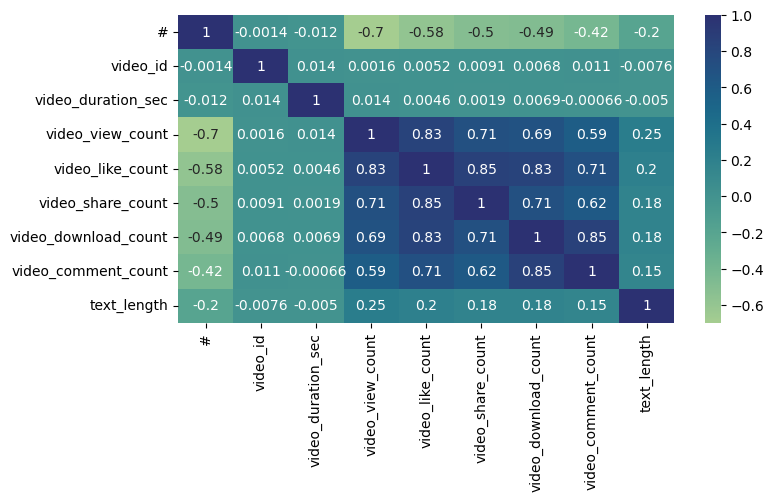

In [25]:
# Create a heatmap to visualize how correlated variables are
### YOUR CODE HERE ###
plt.figure(figsize = (8,4))

sns.heatmap(data_balanced.corr(numeric_only = True),
            annot = True, 
            cmap = 'crest') 

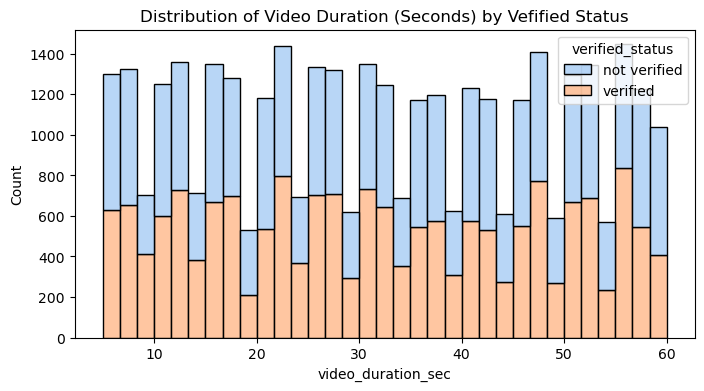

In [26]:
plt.figure(figsize = (8,4))

sns.histplot(x = 'video_duration_sec', data = data_balanced, multiple = 'stack',  palette='pastel', hue = 'verified_status', legend = True) 

plt.title('Distribution of Video Duration (Seconds) by Vefified Status') 
plt.show() 

One of the model assumptions for logistic regression is no severe multicollinearity among the features. Take this into consideration as you examine the heatmap and choose which features to proceed with.

**Question:** What variables are shown to be correlated in the heatmap?

<img src="images/Construct.png" width="100" height="100" align=left>

## **PACE: Construct**

After analysis and deriving variables with close relationships, it is time to begin constructing the model. Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

### **Task 3a. Select variables**

Set your Y and X variables.

Select the outcome variable.

In [27]:
# Select outcome variable
### YOUR CODE HERE ###
y = data_balanced[['verified_status']]

Select the features.

In [28]:
# Select features
### YOUR CODE HERE ###

X = data_balanced[['video_like_count','video_duration_sec','text_length','author_ban_status']]
# Display first few rows of features dataframe
### YOUR CODE HERE ###
X.head()

,video_like_count,video_duration_sec,text_length,author_ban_status
0,19425.0,59,97,under review
1,77355.0,32,107,active
2,97690.0,31,137,active
3,239954.0,25,131,active
4,34987.0,19,128,active


In [29]:
# Check VIF score 
from statsmodels.stats.outliers_influence import variance_inflation_factor 

X_vif = pd.get_dummies(X, columns = ['author_ban_status'], drop_first = True) 
X_vif = X_vif.astype(float)

vif = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
df_vif = pd.DataFrame(vif, index = X_vif.columns, columns = ['VIF']) 
df_vif 



,VIF
video_like_count,1.358683
video_duration_sec,4.103642
text_length,4.578847
author_ban_status_banned,1.116729
author_ban_status_under review,1.127412


### **Task 3b. Train-test split**

Split the data into training and testing sets.

In [30]:
# Split the data into training and testing sets
### YOUR CODE HERE ###
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state =42 ) 

Confirm that the dimensions of the training and testing sets are in alignment.

In [31]:
# Get shape of each training and testing set
### YOUR CODE HERE ###
for i in [X_train, X_test, y_train, y_test]:
    print(f'\n{i.shape}')


(25037, 4)

(10731, 4)

(25037, 1)

(10731, 1)


### **Task 3c. Encode variables**

Check the data types of the features.

In [32]:
# Check data types
### YOUR CODE HERE ###
X.dtypes 

video_like_count      float64
video_duration_sec      int64
text_length             int64
author_ban_status      object
dtype: object

As shown above, the `claim_status` and `author_ban_status` features are each of data type `object` currently. In order to work with the implementations of models through `sklearn`, these categorical features will need to be made numeric. One way to do this is through one-hot encoding.

Encode categorical features in the training set using an appropriate method.

In [33]:
### YOUR CODE HERE ###

from sklearn.preprocessing import OneHotEncoder
X_train_to_encode = X_train[['author_ban_status']]

X_encoder = OneHotEncoder(drop='first', sparse_output=False)
X_train_encoded = X_encoder.fit_transform(X_train_to_encode)

X_train_encoded_df = pd.DataFrame(data=X_train_encoded, columns=X_encoder.get_feature_names_out())
X_train_encoded_df.head() 

,author_ban_status_banned,author_ban_status_under review
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,1.0,0.0
4,0.0,0.0


In [34]:
### YOUR CODE HERE ###
X_train.drop(columns=['author_ban_status']).head()

,video_like_count,video_duration_sec,text_length
33627,350.0,58,97
32177,1203.0,11,103
17038,2427.0,38,96
91,260329.0,37,99
25378,17.0,30,59


In [35]:
### YOUR CODE HERE ###
X_train_final = pd.concat([X_train.drop(columns=[ 'author_ban_status']).reset_index(drop=True), X_train_encoded_df], axis=1)

In [36]:
X_train_final.head()

,video_like_count,video_duration_sec,text_length,author_ban_status_banned,author_ban_status_under review
0,350.0,58,97,0.0,0.0
1,1203.0,11,103,0.0,0.0
2,2427.0,38,96,0.0,0.0
3,260329.0,37,99,1.0,0.0
4,17.0,30,59,0.0,0.0


Check the data type of the outcome variable.

In [37]:
# Check data type of outcome variable
### YOUR CODE HERE ###
y_train.dtypes 

verified_status    object
dtype: object

In [38]:
# Get unique values of outcome variable
### YOUR CODE HERE ###
y_train.values

array([['verified'],
       ['verified'],
       ['not verified'],
       ...,
       ['not verified'],
       ['not verified'],
       ['not verified']], dtype=object)

A shown above, the outcome variable is of data type `object` currently. One-hot encoding can be used to make this variable numeric.

Encode categorical values of the outcome variable the training set using an appropriate method.

In [39]:
# Set up an encoder for one-hot encoding the categorical outcome variable
### YOUR CODE HERE ###
# y_train_final = OneHotEncoder(drop = 'first').fit_transform(y_train).toarray() 
y_train_final = OneHotEncoder(drop= 'first', sparse_output=False).fit_transform(y_train).ravel()
y_train_final

array([1., 1., 0., ..., 0., 0., 0.])

### **Task 3d. Model building**

Construct a model and fit it to the training set.

In [40]:
# Construct a logistic regression model and fit it to the training set
### YOUR CODE HERE ###

clf = LogisticRegression().fit(X_train_final, y_train_final)

<img src="images/Execute.png" width="100" height="100" align=left>

## **PACE: Execute**

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Taks 4a. Results and evaluation**

Evaluate your model.

Encode categorical features in the testing set using an appropriate method.

In [41]:
# Select the testing features that needs to be encoded
### YOUR CODE HERE ###

X_test_to_encode = X_test[['author_ban_status']]

X_test_encoded = X_encoder.fit_transform(X_test_to_encode)

X_test_encoded_df = pd.DataFrame(data=X_test_encoded, columns=X_encoder.get_feature_names_out())

X_test.drop(columns=['author_ban_status']).head()
X_test_final = pd.concat([X_test.drop(columns=[ 'author_ban_status']).reset_index(drop=True), X_test_encoded_df], axis=1)
# Display first few rows
### YOUR CODE HERE ###
X_test_final

,video_like_count,video_duration_sec,text_length,author_ban_status_banned,author_ban_status_under review
0,664.0,14,109,0.0,0.0
1,358492.0,43,111,0.0,1.0
2,56.0,52,64,0.0,1.0
3,356.0,17,61,1.0,0.0
4,2085.0,8,84,1.0,0.0
...,...,...,...,...,...
10726,388.0,58,95,0.0,0.0
10727,265.0,15,110,0.0,0.0
10728,1592.0,51,90,0.0,0.0
10729,143107.0,34,100,0.0,0.0


Test the logistic regression model. Use the model to make predictions on the encoded testing set.

In [42]:
# Use the logistic regression model to get predictions on the encoded testing set
### YOUR CODE HERE ###
y_pred = clf.predict(X_test_final) 

Display the predictions on the encoded testing set.

In [43]:
# Display the predictions on the encoded testing set
### YOUR CODE HERE ###
y_pred

array([1., 0., 1., ..., 1., 0., 0.])

Display the true labels of the testing set.

In [44]:
# Display the true labels of the testing set
### YOUR CODE HERE ###
y_test

,verified_status
26849,verified
1227,not verified
25467,verified
27310,verified
27560,verified
...,...
16758,not verified
28583,verified
23163,verified
1580,not verified


Encode the true labels of the testing set so it can be compared to the predictions.

In [45]:
# Encode the testing outcome variable
y_test_final = OneHotEncoder(drop= 'first', sparse_output=False).fit_transform(y_test).ravel()
# Display the encoded testing outcome variable
y_test_final

array([1., 0., 1., ..., 1., 0., 0.])

Confirm again that the dimensions of the training and testing sets are in alignment since additional features were added.

In [46]:
# Get shape of each training and testing set
### YOUR CODE HERE ###
for i in [X_train_final, X_test_final, y_train_final, y_test_final, y_pred]:
    print(f'\n{i.shape}')


(25037, 5)

(10731, 5)

(25037,)

(10731,)

(10731,)


### **Task 4b. Visualize model results**

Create a confusion matrix to visualize the results of the logistic regression model.

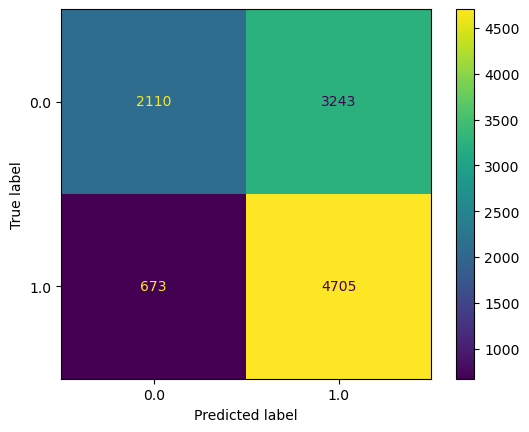

In [47]:
# Compute values for confusion matrix
### YOUR CODE HERE ###
cm = metrics.confusion_matrix(y_test_final, y_pred, labels = clf.classes_) 
# Create display of confusion matrix
### YOUR CODE HERE ###
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = clf.classes_) 
# Plot confusion matrix
### YOUR CODE HERE ###
disp.plot() 
# Display plot
### YOUR CODE HERE ###

Create a classification report that includes precision, recall, f1-score, and accuracy metrics to evaluate the performance of the logistic regression model.

In [48]:
# Create a classification report
### YOUR CODE HERE ###
print('precision', metrics.precision_score(y_test_final, y_pred)) 
print('recall', metrics.recall_score(y_test_final, y_pred)) 
print('accurary', metrics.accuracy_score(y_test_final, y_pred)) 
print('f1 score', metrics.f1_score(y_test_final, y_pred)) 

precision 0.5919728233517866
recall 0.8748605429527705
accurary 0.6350759481874941
f1 score 0.7061383761068587


In [53]:
print( clf.classes_) 

[0. 1.]


In [54]:
from sklearn.metrics import classification_report

target_labels = ['not verified', 'verified']

print(classification_report(y_test_final, y_pred, target_names= target_labels))

              precision    recall  f1-score   support

not verified       0.76      0.39      0.52      5353
    verified       0.59      0.87      0.71      5378

    accuracy                           0.64     10731
   macro avg       0.68      0.63      0.61     10731
weighted avg       0.67      0.64      0.61     10731



### **Task 4c. Interpret model coefficients**

In [50]:
# Get the feature names from the model and the model coefficients (which represent log-odds ratios)
# Place into a DataFrame for readability
### YOUR CODE HERE ###
pd.DataFrame(data = {'Feature Name': clf.feature_names_in_, 
                     'Model Coefficient': clf.coef_[0]}) 

,Feature Name,Model Coefficient
0,video_like_count,-0.000005
1,video_duration_sec,0.000928
2,text_length,0.002224
3,author_ban_status_banned,-0.000003
4,author_ban_status_under review,-0.000002


### **Task 4d. Conclusion**
What are the key takeaways from this project?

What results can be presented from this project?

In [51]:
# Key takeaways and results
# 1. There are some degree of multicollinearity presented among the independent variables, which may affect the stability and interpretability of the model coefficients. 
# 2. Several outliers were identified in the dataset, but these values are reasonable in the context of social media data, where certain videos may go viral and naturally generate extremely high engagement metrics. 
# 3. The logistic regression model achived an accuracy of 64%, which is better than random but not strong. 
# 4. The model demonstrates a high recall score (87%) for predicting unverified accounts. This suggests that the model is more effective at identifying unverified users, but it may exhibit bias toward predicting the unverified status. 
# 5. The estimated beta coefficients are relatively small in magnitude, indicating that the selected features have limited influence on the predicted probability of verification status. 


**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged. 